正在构建转移矩阵...
正在计算特征值与谱展开...
正在绘制 KDE 与 CDF 对比图...


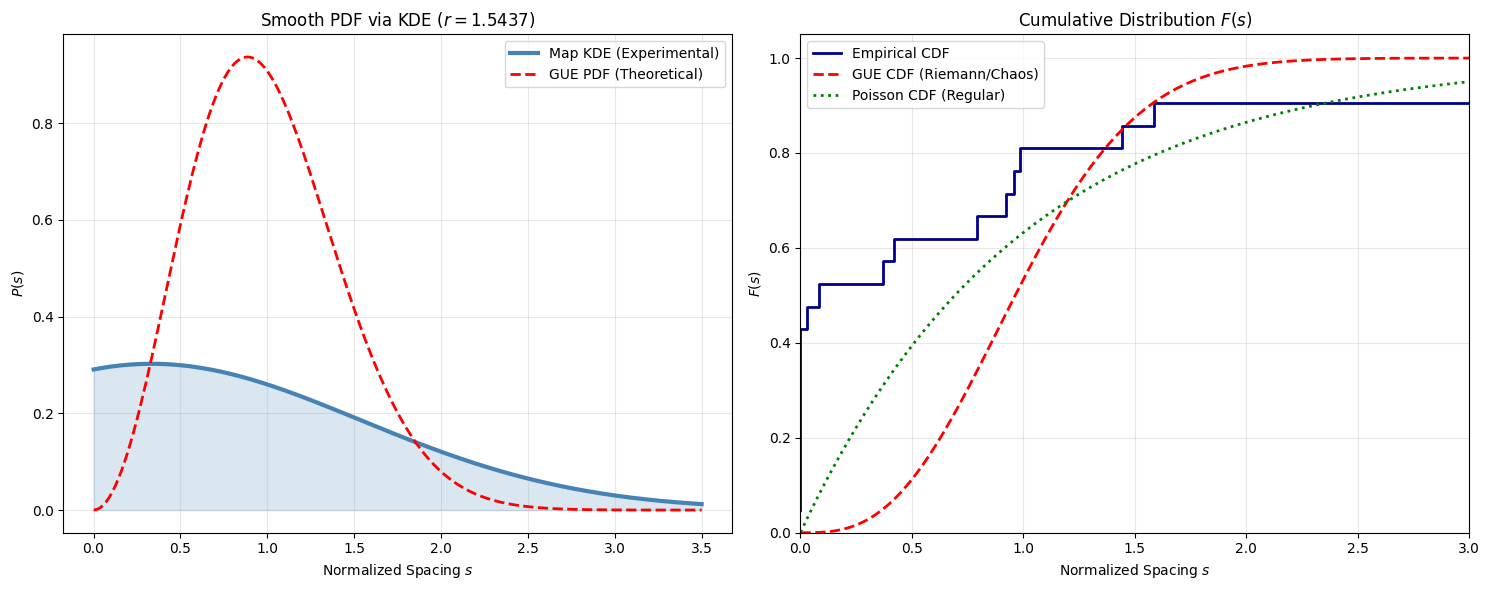

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.special import erf

# ==========================================
# 1. 动力学参数设置与 Ulam 矩阵生成
# ==========================================
r = 1.5437       # Misiurewicz 点 (带合并点)
N = 1000         # 网格分辨率
epsilon = 0.008  # 扩散算子扰动

edges = np.linspace(-1, 1, N + 1)
centers = (edges[:-1] + edges[1:]) / 2
P = np.zeros((N, N))

print("正在构建转移矩阵...")
for j in range(N):
    x_next = 1 - r * (centers[j]**2)
    dist = np.abs(centers - x_next)
    kernel = np.exp(-dist**2 / (2 * epsilon**2))
    P[:, j] = kernel / kernel.sum() 

# ==========================================
# 2. 提取特征谱与全局谱展开 (Unfolding)
# ==========================================
print("正在计算特征值与谱展开...")
eigvals = np.linalg.eigvals(P)
mags = np.abs(eigvals)

# 过滤两端噪声，提取中间的“冰山”特征
mags_filtered = np.sort(mags[(mags > 0.05) & (mags < 0.99)])
spacings = np.diff(mags_filtered)

# 均值归一化 (让平均间距强制为 1)
s = spacings / np.mean(spacings)

# ==========================================
# 3. 定义理论 CDF / PDF 函数
# ==========================================
def gue_pdf(x):
    return (32 / (np.pi**2)) * (x**2) * np.exp(-(4 / np.pi) * (x**2))

def gue_cdf(x):
    # 黎曼零点/GUE 的理论累积分布
    return erf(2 * x / np.sqrt(np.pi)) - (4 * x / np.pi) * np.exp(-4 * x**2 / np.pi)

def poisson_cdf(x):
    return 1 - np.exp(-x)

# ==========================================
# 4. 绘图：KDE (平滑概率) 与 CDF (累积概率)
# ==========================================
print("正在绘制 KDE 与 CDF 对比图...")
plt.figure(figsize=(15, 6))
x_plot = np.linspace(0.001, 3.5, 200)

# --- 左图：KDE (核密度估计) 替代直方图 ---
plt.subplot(1, 2, 1)
kde = gaussian_kde(s)
# 绘制我们实验数据的平滑曲线
plt.plot(x_plot, kde(x_plot), color='steelblue', lw=3, label='Map KDE (Experimental)')
# 绘制理论曲线
plt.plot(x_plot, gue_pdf(x_plot), 'r--', lw=2, label='GUE PDF (Theoretical)')
plt.fill_between(x_plot, kde(x_plot), alpha=0.2, color='steelblue')

plt.title(rf"Smooth PDF via KDE ($r={r}$)")
plt.xlabel(r"Normalized Spacing $s$")
plt.ylabel(r"$P(s)$")
plt.legend()
plt.grid(alpha=0.3)

# --- 右图：CDF (累积分布) ---
plt.subplot(1, 2, 2)
# 经验 CDF (Empirical CDF) - 无参数，最真实的物理分布
s_sorted = np.sort(s)
y_ecdf = np.arange(1, len(s_sorted) + 1) / len(s_sorted)

# 使用 step 绘制经验 CDF 的阶梯感
plt.step(s_sorted, y_ecdf, where='post', color='darkblue', lw=2, label='Empirical CDF')
plt.plot(x_plot, gue_cdf(x_plot), 'r--', lw=2, label='GUE CDF (Riemann/Chaos)')
plt.plot(x_plot, poisson_cdf(x_plot), 'g:', lw=2, label='Poisson CDF (Regular)')

plt.title(r"Cumulative Distribution $F(s)$")
plt.xlabel(r"Normalized Spacing $s$")
plt.ylabel(r"$F(s)$")
plt.xlim(0, 3)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()